In [3]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_superstore.csv to cleaned_superstore (1).csv


In [4]:
import os
os.listdir()


['.config',
 'cleaned_superstore.csv',
 'cleaned_superstore (1).csv',
 'sample_data']

In [5]:
import pandas as pd

df = pd.read_csv("cleaned_superstore.csv")


In [6]:
# First 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,Order Date_Month,Order Date_Year,Ship Date_Month,Ship Date_Year,Revenue,Profit Margin %
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,November,2016,November,2016,261.9600,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,November,2016,November,2016,731.9400,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,June,2016,June,2016,14.6200,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,October,2015,October,2015,957.5775,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,October,2015,October,2015,22.3680,11.25


In [7]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID            9994 non-null   int64  
 1   Order ID          9994 non-null   object 
 2   Order Date        9994 non-null   object 
 3   Ship Date         9994 non-null   object 
 4   Ship Mode         9994 non-null   object 
 5   Customer ID       9994 non-null   object 
 6   Customer Name     9994 non-null   object 
 7   Segment           9994 non-null   object 
 8   Country           9994 non-null   object 
 9   City              9994 non-null   object 
 10  State             9994 non-null   object 
 11  Postal Code       9994 non-null   int64  
 12  Region            9994 non-null   object 
 13  Product ID        9994 non-null   object 
 14  Category          9994 non-null   object 
 15  Sub-Category      9994 non-null   object 
 16  Product Name      9994 non-null   object 


In [8]:
# Statistical summary
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Order Date_Year,Ship Date_Year,Revenue,Profit Margin %
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,2015.737442,229.858001,12.031390
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,1.126141,623.245101,46.675436
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,2014.000000,0.444000,-275.000000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,2015.000000,17.280000,7.500000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,2016.000000,54.490000,27.000000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,2017.000000,209.940000,36.250000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,2018.000000,22638.480000,50.000000


In [9]:
# Column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Order Date_Month', 'Order Date_Year', 'Ship Date_Month',
       'Ship Date_Year', 'Revenue', 'Profit Margin %'],
      dtype='object')

In [10]:
total_revenue = df["Revenue"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 2297200.8603000003


In [11]:
total_profit = df["Profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 286397.0217


In [12]:
total_orders = df["Order ID"].nunique()
print("Total Orders:", total_orders)

Total Orders: 5009


In [13]:
average_order = total_revenue / total_orders
print("Average Order Value:", round(average_order,2))

Average Order Value: 458.61


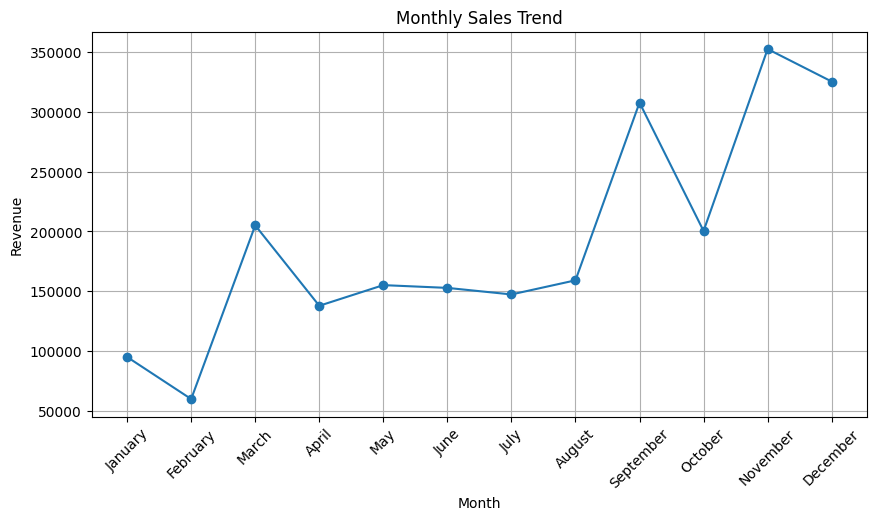

In [14]:
import matplotlib.pyplot as plt

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales = (
    df.groupby("Order Date_Month")["Revenue"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Revenue, dtype: float64


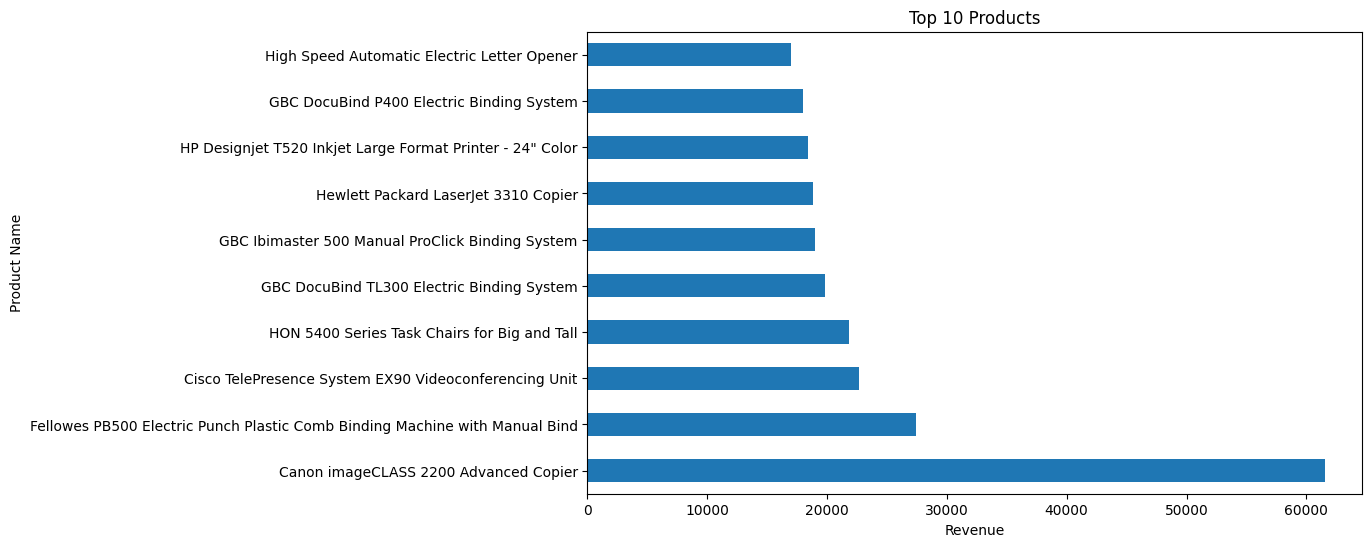

In [15]:
top_products = (
    df.groupby("Product Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

plt.figure(figsize=(10,6))
top_products.plot(kind="barh")
plt.title("Top 10 Products")
plt.xlabel("Revenue")
plt.show()

Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Newell 308                                                          8.400
Name: Revenue, dtype: float64


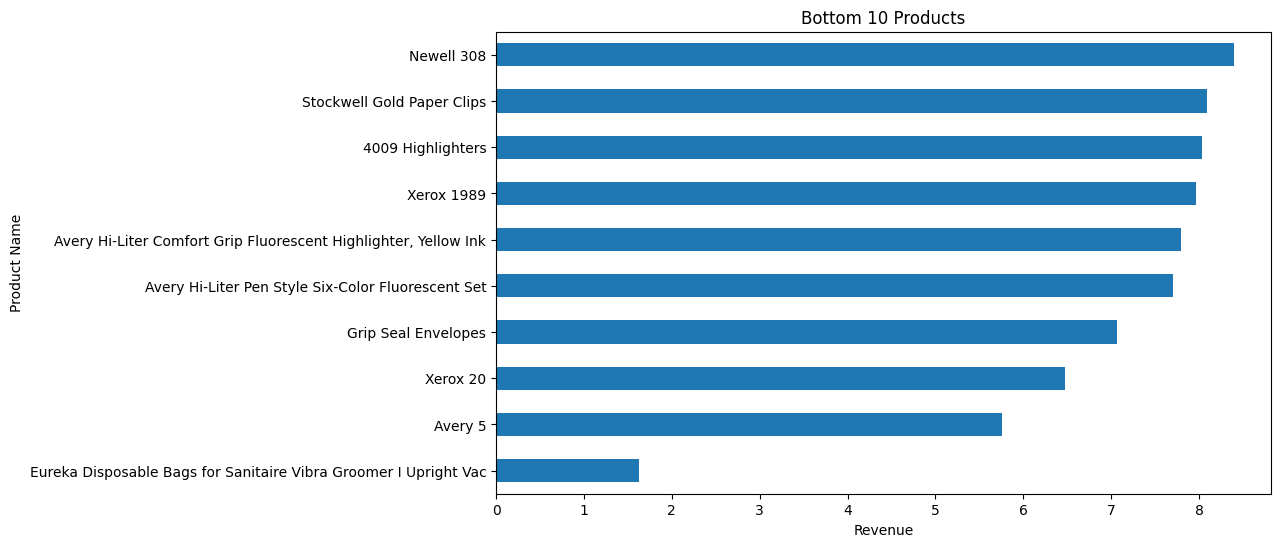

In [16]:
bottom_products = (
    df.groupby("Product Name")["Revenue"]
      .sum()
      .sort_values()
      .head(10)
)

print(bottom_products)

plt.figure(figsize=(10,6))
bottom_products.plot(kind="barh")
plt.title("Bottom 10 Products")
plt.xlabel("Revenue")
plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


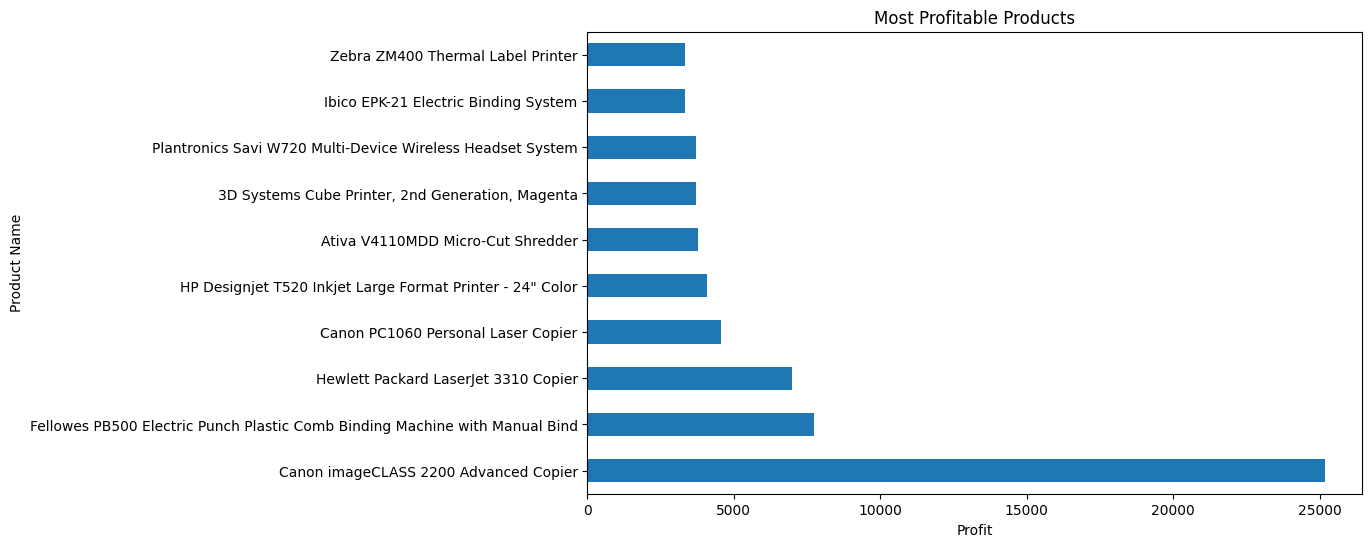

In [17]:
top_profit = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_profit)

plt.figure(figsize=(10,6))
top_profit.plot(kind="barh")
plt.title("Most Profitable Products")
plt.xlabel("Profit")
plt.show()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Revenue, dtype: float64


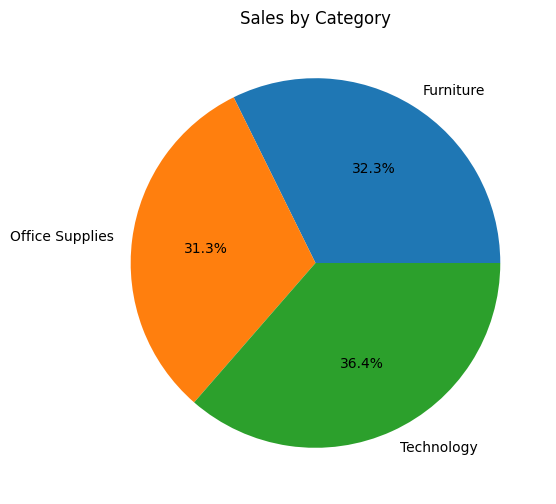

In [18]:
sales_category = df.groupby("Category")["Revenue"].sum()

print(sales_category)

plt.figure(figsize=(6,6))
sales_category.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Sales by Category")
plt.show()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


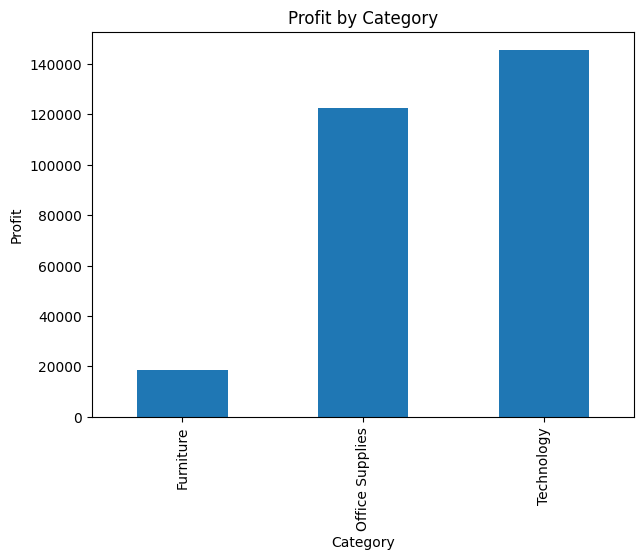

In [19]:
profit_category = df.groupby("Category")["Profit"].sum()

print(profit_category)

plt.figure(figsize=(7,5))
profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

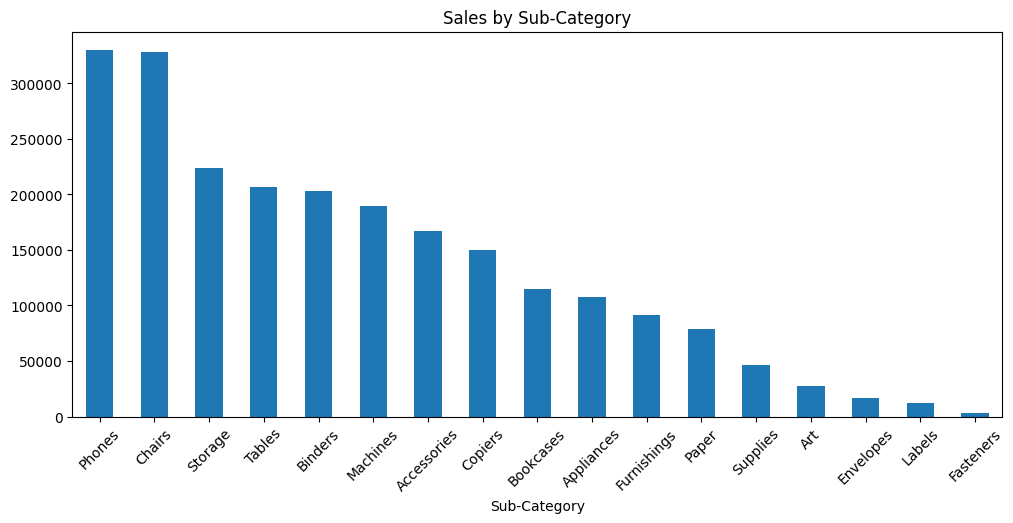

In [20]:
subcategory = (
    df.groupby("Sub-Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))
subcategory.plot(kind="bar")
plt.title("Sales by Sub-Category")
plt.xticks(rotation=45)
plt.show()

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Revenue, dtype: float64


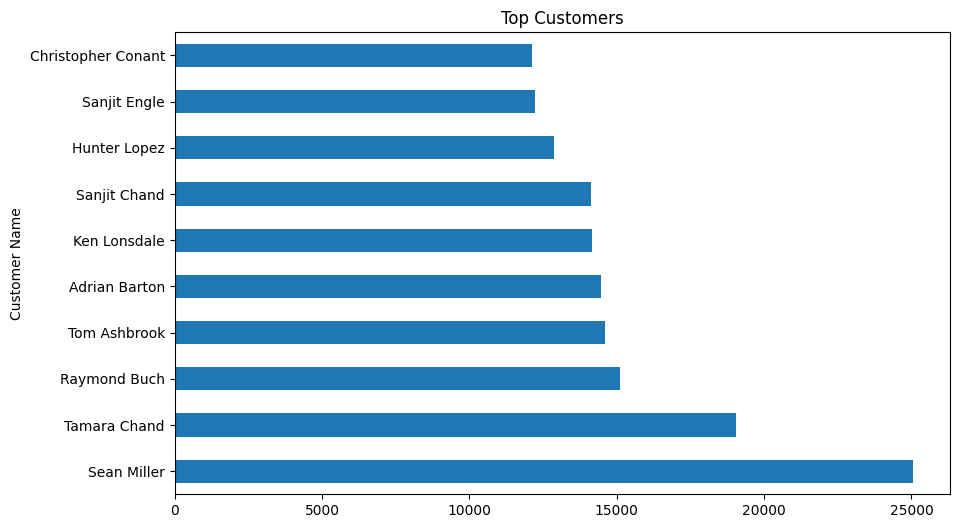

In [21]:
top_customers = (
    df.groupby("Customer Name")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_customers)

plt.figure(figsize=(10,6))
top_customers.plot(kind="barh")
plt.title("Top Customers")
plt.show()

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Revenue, dtype: float64


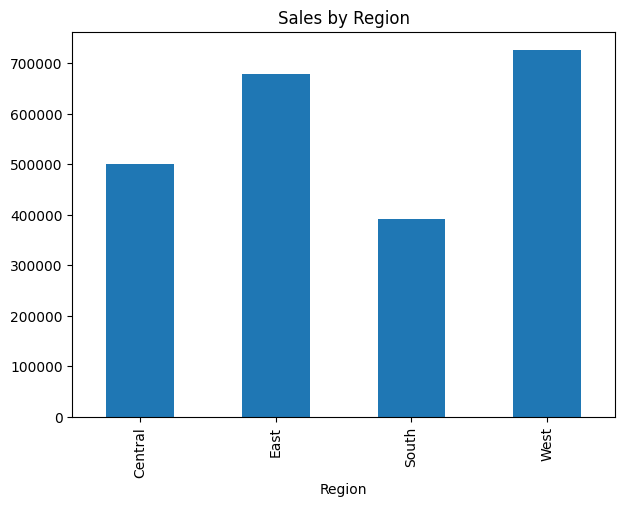

In [22]:
region_sales = df.groupby("Region")["Revenue"].sum()

print(region_sales)

plt.figure(figsize=(7,5))
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


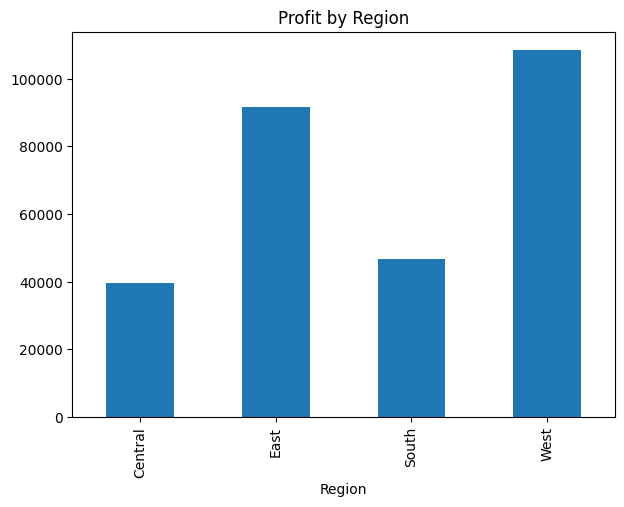

In [23]:
region_profit = df.groupby("Region")["Profit"].sum()

print(region_profit)

plt.figure(figsize=(7,5))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.show()

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Revenue, dtype: float64


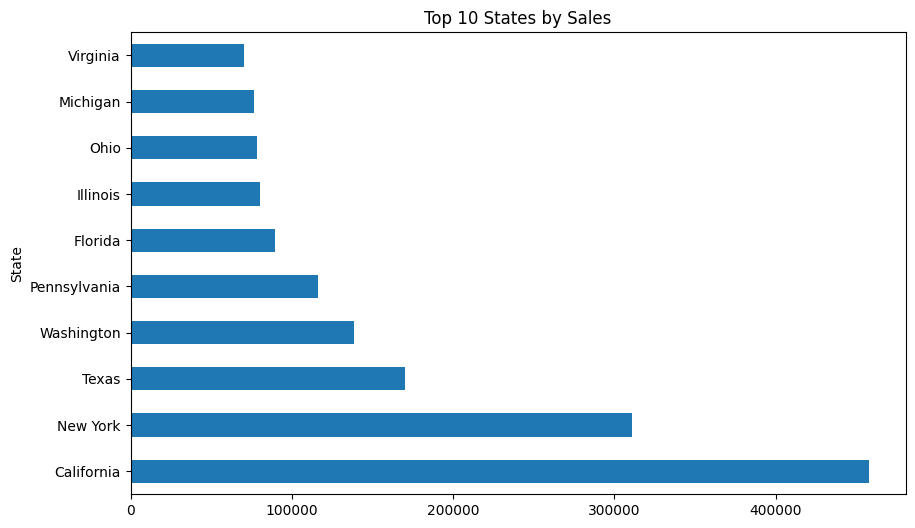

In [24]:
state_sales = (
    df.groupby("State")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(state_sales)

plt.figure(figsize=(10,6))
state_sales.plot(kind="barh")
plt.title("Top 10 States by Sales")
plt.show()